In [62]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scipy

## Load Processed Seurat Object

In [6]:
adata = ad.read_h5ad("../R-Notebooks/mouse.anndata.h5ad")
adata

AnnData object with n_obs × n_vars = 913 × 30186
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.hist', 'V1', 'plate', 'celltype', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1.2', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'clusters.main.lineage', 'pseudotime'
    obsm: 'pca', 'tsne', 'umap'
    layers: 'counts', 'data'
    obsp: 'nn', 'snn'

## Pseudotime

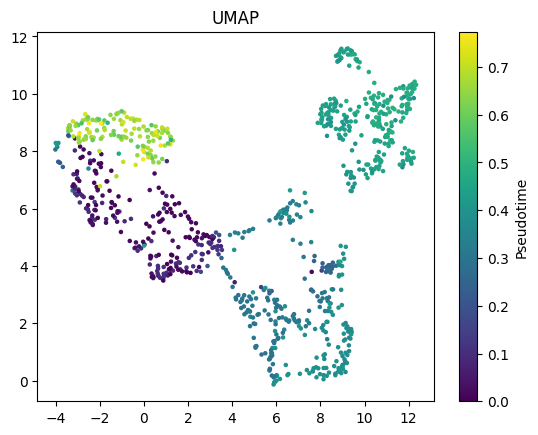

In [192]:
sc = plt.scatter(adata.obsm['umap'][:, 0], adata.obsm['umap'][:, 1], s=5, c=adata.obs['pseudotime'].to_numpy(dtype=float), cmap='viridis')
cb = plt.colorbar(sc, label="Pseudotime")
plt.title("UMAP")
plt.show()

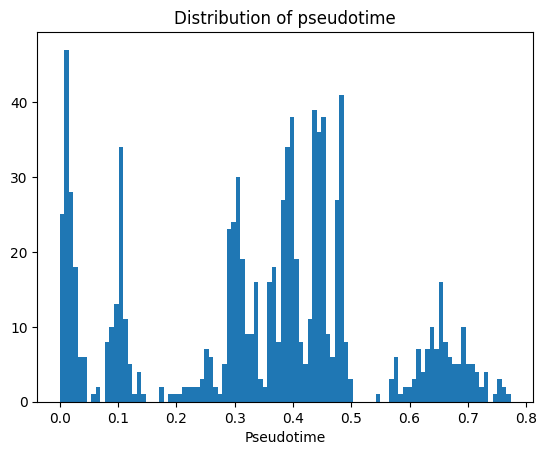

In [191]:
plt.hist(adata.obs['pseudotime'].to_numpy(dtype=float), bins=100);
plt.xlabel("Pseudotime")
plt.title("Distribution of pseudotime")
plt.show()

## Correlation Sliding Window

### Fixed time width

C:\Users\willi\AppData\Local\Temp\ipykernel_11692\3847957778.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = scipy.stats.pearsonr(x1, x2).statistic


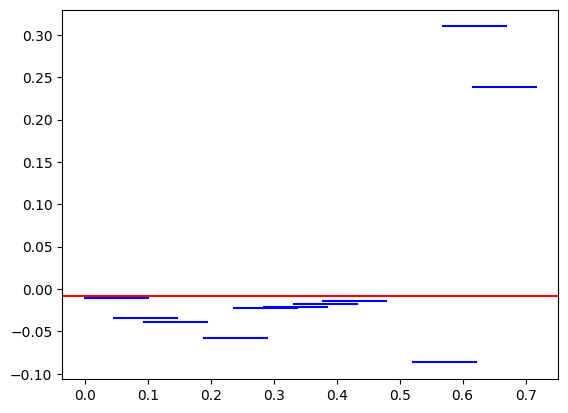

In [200]:
g = 0
count_pair = adata.layers['counts'][:, g:g+2].toarray()
pseudotime = adata.obs['pseudotime'].to_numpy(dtype=float)

corr = scipy.stats.pearsonr(count_pair[:, 0], count_pair[:, 1]).statistic
plt.axhline(float(corr), color="red")

width = 0.1

corrs = []

for t in np.linspace(width, 1, 20):

    mask = (pseudotime > t - width) & (pseudotime < t)

    if mask.sum() == 0:
        corrs.append(None)
        continue

    x1 = count_pair[:, 0][mask]
    x2 = count_pair[:, 1][mask]

    if x1.size < 2:
        corrs.append(None)
        continue

    corr = scipy.stats.pearsonr(x1, x2).statistic
    if np.isnan(corr):
        corrs.append(None)
    else:
        corrs.append(float(corr))
        plt.plot([t - width, t], [corr, corr], color="blue")

#plt.plot(np.linspace(width, 1, 10), corrs)

### Fixed cell width

C:\Users\willi\AppData\Local\Temp\ipykernel_11692\1317051649.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = scipy.stats.pearsonr(x1, x2).statistic


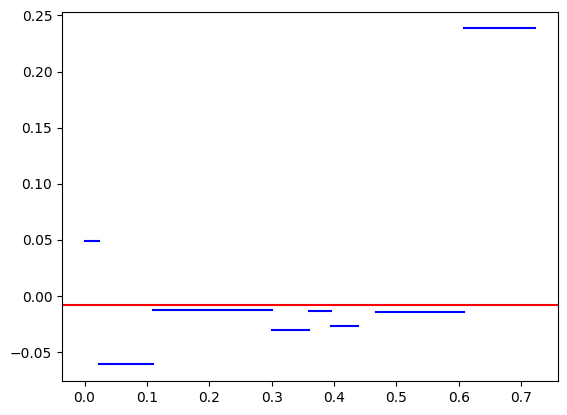

In [201]:
g = 0
count_pair = adata.layers['counts'][:, g:g+2].toarray()
pseudotime = adata.obs['pseudotime'].to_numpy(dtype=float)

corr = scipy.stats.pearsonr(count_pair[:, 0], count_pair[:, 1]).statistic
plt.axhline(float(corr), color="red")

idxs = pseudotime.argsort()

x1_sort = count_pair[:, 0][idxs]
x2_sort = count_pair[:, 1][idxs]
t_sort = pseudotime[idxs]

size = 100
step = 100

corrs = []

for i in range(0, x1_sort.size - size, step):

    x1 = x1_sort[i:(i + size)]
    x2 = x2_sort[i:(i + size)]

    t1 = t_sort[i]
    t2 = t_sort[i + size]

    corr = scipy.stats.pearsonr(x1, x2).statistic
    if np.isnan(corr):
        corrs.append(None)
    else:
        corrs.append(float(corr))
        plt.plot([t1, t2], [corr, corr], color="blue")

# Scanpy Python analysis

- loading object from seurat analysis
- should try out doing full analysis in python
    - however may be tricky to assign cell types, as done manually in R code

In [147]:
adata

AnnData object with n_obs × n_vars = 913 × 30186
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.hist', 'V1', 'plate', 'celltype', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1.2', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'clusters.main.lineage', 'pseudotime'
    obsm: 'pca', 'tsne', 'umap'
    layers: 'counts', 'data'
    obsp: 'nn', 'snn'

In [151]:
import scanpy as sc

In [156]:
sc.pp.neighbors(adata, use_rep="pca", n_pcs=15)

c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [159]:
sc.tl.paga(adata, groups="seurat_clusters")

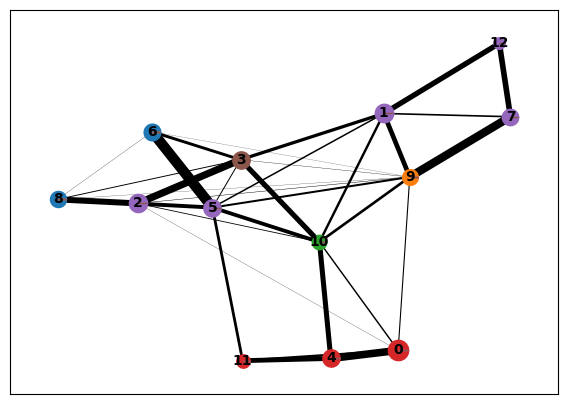

In [168]:
sc.pl.paga(adata, color="clusters.main.lineage")

In [169]:
sc.tl.draw_graph(adata, init_pos="paga")

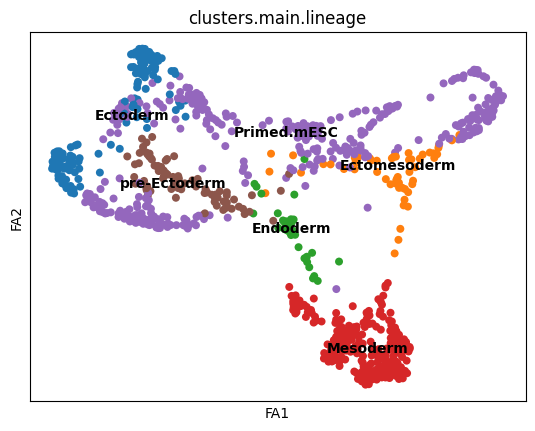

In [173]:
sc.pl.draw_graph(adata, color="clusters.main.lineage", legend_loc="on data")